
# Presentation companion — spatio-temporal kriging

High-resolution slide-ready plots for the class presentation. Every figure is
rendered with enlarged axis labels / legends and saved as PNG under
`presentation_figures/`. A short narrative follows each figure for the slide.


In [1]:

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.spatial.distance import cdist

import kriging_lib as K

SEED = 20260421
rng = np.random.default_rng(SEED)

HERE = Path.cwd()
PFIG = HERE / "presentation_figures"
PFIG.mkdir(exist_ok=True)
DATADIR = HERE / "kriging_data"

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2.0,
})

def savefig(fig, name):
    out = PFIG / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print(f"  saved {out.name}")



## Shared data loading


In [2]:

def load_period(tag):
    meta = pd.read_csv(DATADIR / f"stations_meta_{tag}.csv")
    obs = pd.read_csv(DATADIR / f"stations_obs_{tag}.csv", parse_dates=["time"])
    full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")
    wide = obs.pivot_table(index="time", columns="station_id", values="temp").reindex(full_idx)
    return meta.set_index("station_id"), wide

meta_sum, wide_sum = load_period("summer_2020")
meta_aut, wide_aut = load_period("autumn_2020")

TARGET_LAT, TARGET_LON = 33.1, -116.6
for meta in (meta_sum, meta_aut):
    meta["dist_km"] = K.haversine_km(
        TARGET_LAT, TARGET_LON, meta["latitude"].values, meta["longitude"].values,
    )

print("Summer 2020:", wide_sum.shape[1], "stations x", wide_sum.shape[0], "hours")
print("Autumn 2020:", wide_aut.shape[1], "stations x", wide_aut.shape[0], "hours")


Summer 2020: 29 stations x 168 hours
Autumn 2020: 26 stations x 168 hours


/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_28572/2486605091.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")
/var/folders/kz/h61ygg1n52d82982x3q0zf2r0000gn/T/ipykernel_28572/2486605091.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="H")



---

# SLIDE 1 — Data overview

Narrative (paste into slide notes):

- We pull **29 hourly NOAA weather stations** (via Meteostat) around San Diego for two one-week study windows matching the reference paper: **14–20 June 2020** (summer) and **14–20 September 2020** (autumn).
- Target point: the inferred HPWREN greenhouse-like site at **33.1 °N, −116.6 °W**, ~860 m elevation.
- Stations range from **sea level to ~2 000 m elevation**, and from **4 km to 170 km** from the target — so the network spans very heterogeneous terrain, which turns out to matter for kriging accuracy.
- Every station reports hourly temperature; after basic cleaning we keep only stations with ≥ 120 / 168 hours of data.


  saved slide1_station_map.png


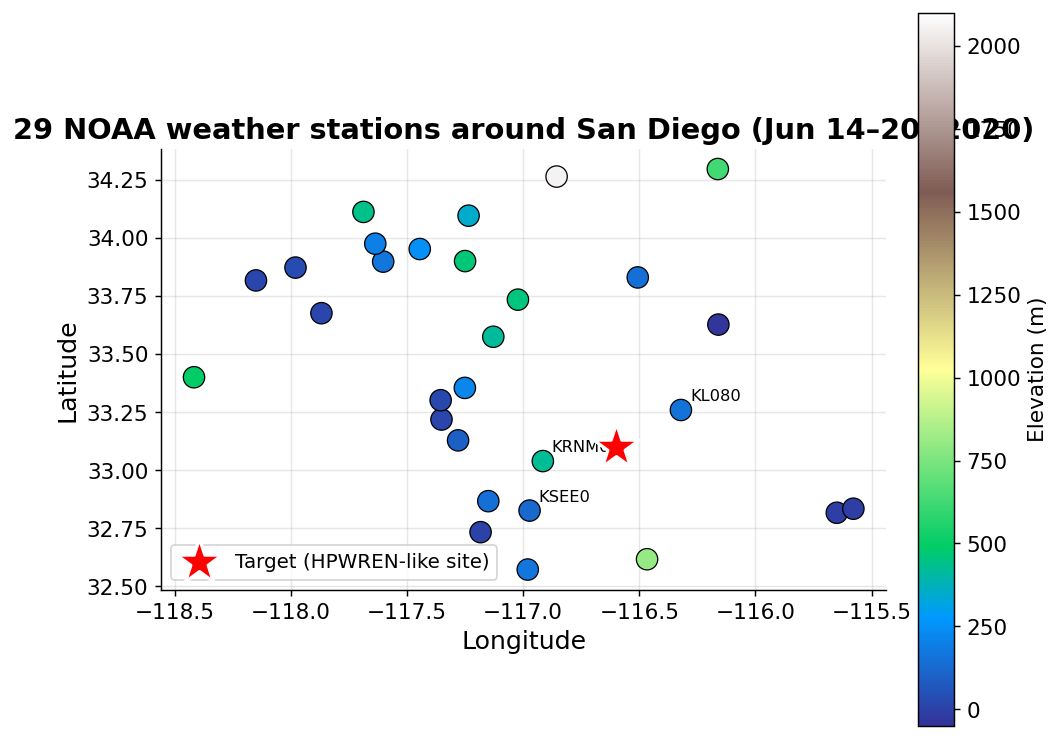

In [3]:

fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(meta_sum["longitude"], meta_sum["latitude"],
                c=meta_sum["elevation"], cmap="terrain",
                s=140, edgecolor="black", linewidth=0.7, vmin=-50, vmax=2100,
                zorder=3)
ax.scatter([TARGET_LON], [TARGET_LAT], marker="*", color="red",
           s=700, edgecolor="white", linewidth=1.8, zorder=5,
           label="Target (HPWREN-like site)")
for sid, row in meta_sum.iterrows():
    if row["dist_km"] < 50:
        ax.annotate(sid, (row["longitude"], row["latitude"]),
                    fontsize=9, color="black", xytext=(5, 5),
                    textcoords="offset points", zorder=4)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"{len(meta_sum)} NOAA weather stations around San Diego (Jun 14–20, 2020)")
ax.legend(loc="lower left", fontsize=11)
cb = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.04)
cb.set_label("Elevation (m)", fontsize=12)
ax.set_aspect("equal")
fig.tight_layout()
savefig(fig, "slide1_station_map")
plt.show()


  saved slide1_time_series.png


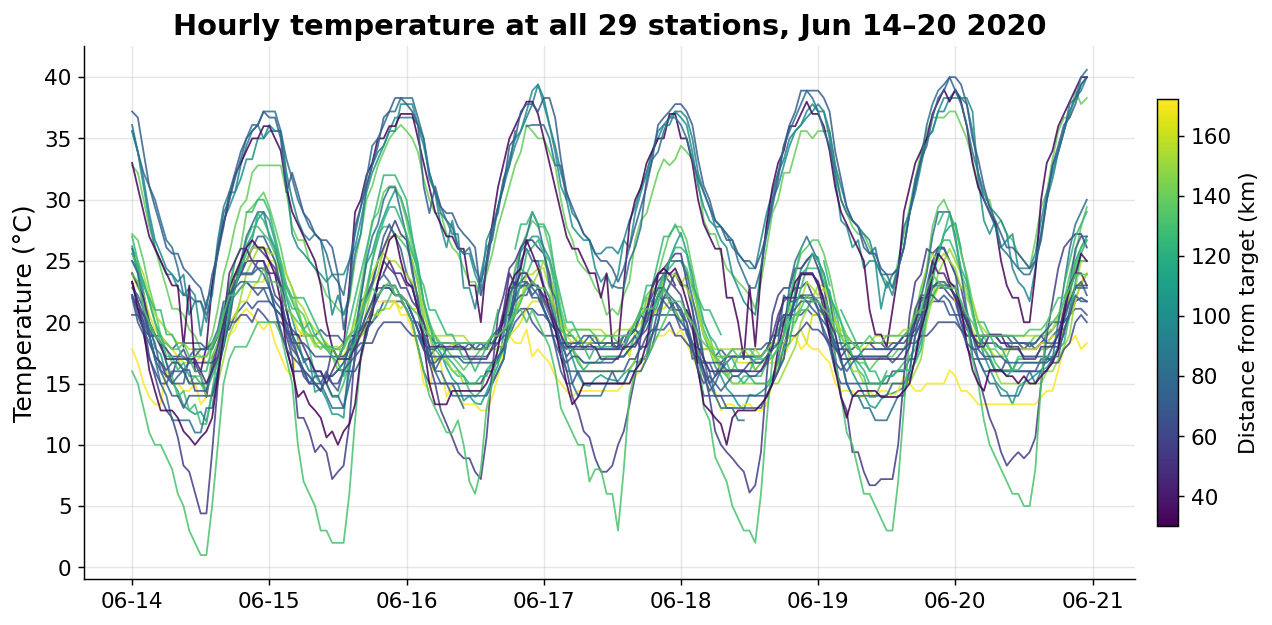

In [4]:

fig, ax = plt.subplots(figsize=(10, 5))
n = len(wide_sum.columns)
norm = Normalize(meta_sum["dist_km"].min(), meta_sum["dist_km"].max())
cmap = cm.viridis

for sid in wide_sum.columns:
    color = cmap(norm(meta_sum.loc[sid, "dist_km"]))
    ax.plot(wide_sum.index, wide_sum[sid], color=color, lw=1.0, alpha=0.85)

ax.set_ylabel("Temperature (°C)")
ax.set_title(f"Hourly temperature at all {n} stations, Jun 14–20 2020")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, shrink=0.8, fraction=0.04, pad=0.02)
cb.set_label("Distance from target (km)", fontsize=12)
fig.tight_layout()
savefig(fig, "slide1_time_series")
plt.show()


  saved slide1_distance_elevation.png


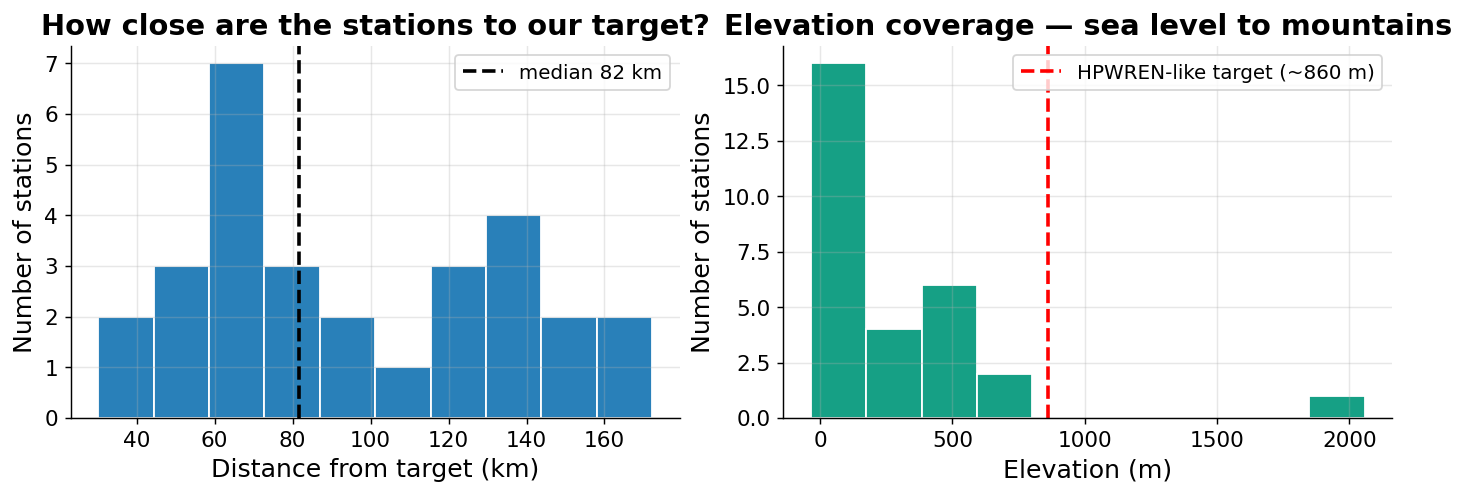

Station count:              29
Distance range:             30.1 – 172.2 km
Elevation range:            -35 – 2058 m
Observation completeness:   99.2% (non-missing hours)


In [5]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(meta_sum["dist_km"], bins=10, color="#2980b9", edgecolor="white")
axes[0].set_xlabel("Distance from target (km)")
axes[0].set_ylabel("Number of stations")
axes[0].set_title("How close are the stations to our target?")
axes[0].axvline(meta_sum["dist_km"].median(), ls="--", color="black",
                label=f"median {meta_sum['dist_km'].median():.0f} km")
axes[0].legend()

elev = meta_sum["elevation"].dropna()
axes[1].hist(elev, bins=10, color="#16a085", edgecolor="white")
axes[1].set_xlabel("Elevation (m)")
axes[1].set_ylabel("Number of stations")
axes[1].set_title("Elevation coverage — sea level to mountains")
axes[1].axvline(860, ls="--", color="red", label="HPWREN-like target (~860 m)")
axes[1].legend()

fig.tight_layout()
savefig(fig, "slide1_distance_elevation")
plt.show()

print(f"Station count:              {len(meta_sum)}")
print(f"Distance range:             {meta_sum['dist_km'].min():.1f} – {meta_sum['dist_km'].max():.1f} km")
print(f"Elevation range:            {elev.min():.0f} – {elev.max():.0f} m")
print(f"Observation completeness:   {wide_sum.notna().mean().mean() * 100:.1f}% (non-missing hours)")



---

# SLIDE 2 — The variogram

Narrative:

- The **semivariogram** $\gamma(h)$ quantifies how *dissimilar* two observations tend to be as a function of the lag $h$ between them. Small lag → small $\gamma$ (nearby points agree); large lag → flattens out at the **sill** (variance of the field).
- To handle *both* space and time, we use the paper's **sum-metric** model:
  $$\gamma(h, u) = n\cdot\mathbf{1}\{h>0 \text{ or } u>0\} + \gamma_s(h) + \gamma_t(u) + \gamma_j\!\left(\sqrt{h^2 + (k u)^2}\right)$$
  A purely spatial component $\gamma_s$, a purely temporal component $\gamma_t$, and a **joint** component $\gamma_j$ that couples space and time through the anisotropy scale $k$ (units of km per hour).
- We estimate $\gamma(h, u)$ empirically on binned station-pair lags, then fit the sum-metric model by weighted least squares. The fitted model enters the kriging equations.


  saved slide2_variogram_1d.png


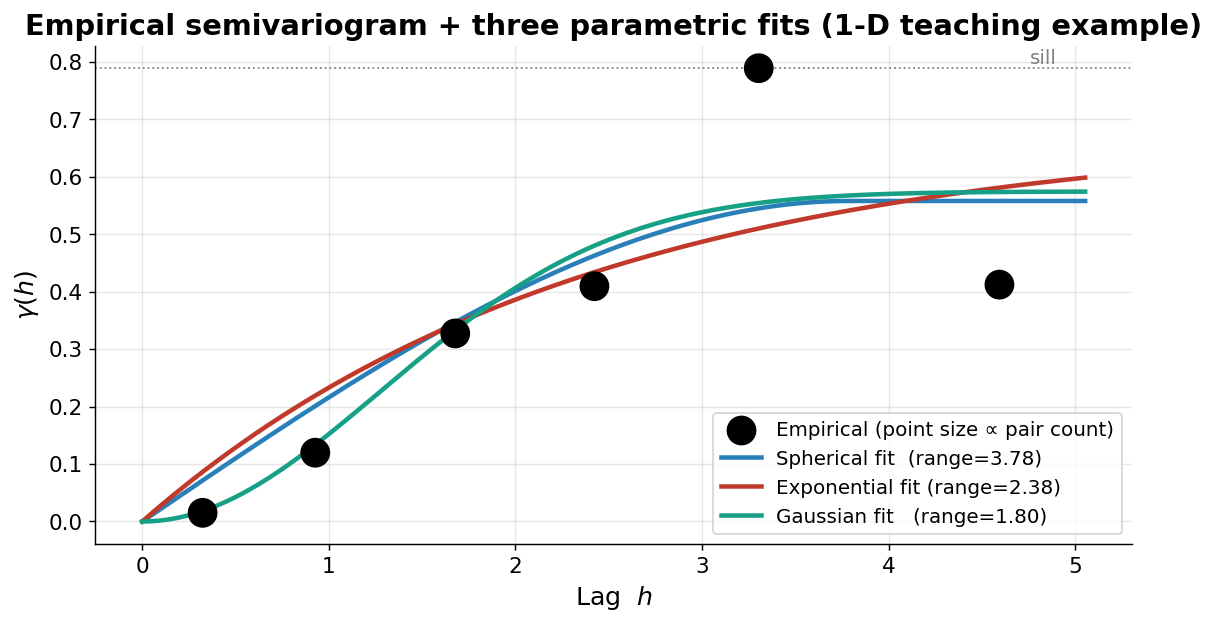

In [6]:

rng_demo = np.random.default_rng(SEED)
x_obs = np.sort(rng_demo.uniform(0.2, 9.8, 12))
y_obs = np.sin(x_obs) + 0.1 * x_obs + rng_demo.normal(0, 0.05, x_obs.size)

ii, jj = np.triu_indices(len(x_obs), k=1)
h_pairs = np.abs(x_obs[ii] - x_obs[jj])
d_pairs = (y_obs[ii] - y_obs[jj]) ** 2
h_c, g_c, n_c = K.empirical_variogram_1d(h_pairs, d_pairs, n_bins=6)

from scipy.optimize import least_squares
def fit_model(model_fn):
    def resid(theta):
        s, r, n_ = theta
        return model_fn(h_c, s, r, n_) - g_c
    th0 = [float(np.nanmax(g_c)), float(np.nanmedian(h_c)), 0.05]
    lb = [1e-6, 1e-6, 0.0]
    ub = [np.inf, np.inf, np.inf]
    res = least_squares(resid, th0, bounds=(lb, ub), max_nfev=2000)
    return res.x

th_sph = fit_model(K.spherical)
th_exp = fit_model(K.exponential)
th_gau = fit_model(K.gaussian)

h_fine = np.linspace(0, h_c.max() * 1.1, 300)
fig, ax = plt.subplots(figsize=(9, 5))

sizes = 40 + 200 * n_c / n_c.max()
ax.scatter(h_c, g_c, s=sizes, color="black", zorder=5,
           label="Empirical (point size ∝ pair count)")
ax.plot(h_fine, K.spherical(h_fine, *th_sph), color="#2980b9", lw=2.5,
        label=f"Spherical fit  (range={th_sph[1]:.2f})")
ax.plot(h_fine, K.exponential(h_fine, *th_exp), color="#c0392b", lw=2.5,
        label=f"Exponential fit (range={th_exp[1]:.2f})")
ax.plot(h_fine, K.gaussian(h_fine, *th_gau), color="#16a085", lw=2.5,
        label=f"Gaussian fit   (range={th_gau[1]:.2f})")
ax.axhline(float(np.nanmax(g_c)), ls=":", color="gray", lw=1)
ax.text(h_fine[-1] * 0.97, float(np.nanmax(g_c)),
        "sill", va="bottom", ha="right", color="gray", fontsize=11)
ax.set_xlabel("Lag  $h$")
ax.set_ylabel(r"$\gamma(h)$")
ax.set_title("Empirical semivariogram + three parametric fits (1-D teaching example)")
ax.legend(loc="lower right")
fig.tight_layout()
savefig(fig, "slide2_variogram_1d")
plt.show()


  saved slide2_st_variogram.png


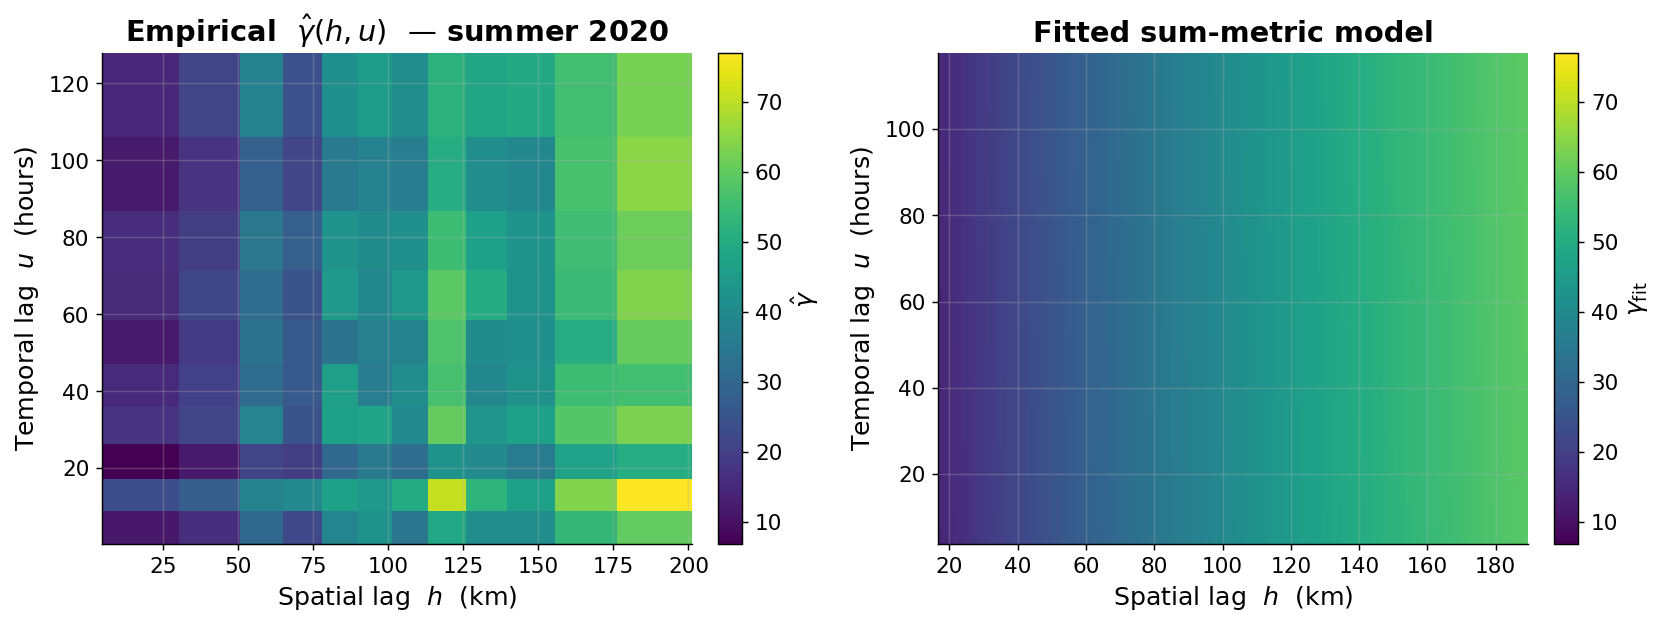

Fitted sum-metric parameters (summer 2020):
  nugget = 8.421
  spatial  sill=54.32, range=245.9 km
  temporal sill=18.27, range=3589.8 h
  joint    sill=0.00, range=10386.1
  anisotropy k  = 0.00 km/hour


In [7]:

def panel_from_wide(meta, wide):
    stations = [s for s in wide.columns if s in meta.index]
    wide = wide[stations]
    xy = np.column_stack([meta.loc[stations, "latitude"].values,
                          meta.loc[stations, "longitude"].values])
    dist = np.zeros((len(stations), len(stations)))
    for i in range(len(stations)):
        dist[i] = K.haversine_km(xy[i, 0], xy[i, 1], xy[:, 0], xy[:, 1])
    return stations, wide.values.T, dist, xy

stations_s, Y_s, dist_s, xy_s = panel_from_wide(meta_sum, wide_sum)
t_hours = np.arange(Y_s.shape[1], dtype=float)
H, U, Gamma, Nc = K.empirical_st_variogram(
    Y_s, dist_s, t_axis=t_hours, max_pairs=80000,
    rng=np.random.default_rng(SEED),
)
p, _ = K.fit_sum_metric(H, U, Gamma, Nc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vmin = np.nanmin(Gamma); vmax = np.nanmax(Gamma)
im = axes[0].pcolormesh(H, U, Gamma, cmap="viridis", shading="auto",
                        vmin=vmin, vmax=vmax)
axes[0].set_xlabel("Spatial lag  $h$  (km)")
axes[0].set_ylabel("Temporal lag  $u$  (hours)")
axes[0].set_title("Empirical  $\\hat\\gamma(h,u)$  — summer 2020")
cb = fig.colorbar(im, ax=axes[0], fraction=0.045, pad=0.04)
cb.set_label(r"$\hat\gamma$")

H_fine = np.linspace(np.nanmin(H), np.nanmax(H), 120)
U_fine = np.linspace(np.nanmin(U), np.nanmax(U), 80)
Hf, Uf = np.meshgrid(H_fine, U_fine, indexing="ij")
Gfit = K.gamma_sum_metric(Hf, Uf, p)
im2 = axes[1].pcolormesh(Hf, Uf, Gfit, cmap="viridis", shading="auto",
                         vmin=vmin, vmax=vmax)
axes[1].set_xlabel("Spatial lag  $h$  (km)")
axes[1].set_ylabel("Temporal lag  $u$  (hours)")
axes[1].set_title("Fitted sum-metric model")
cb2 = fig.colorbar(im2, ax=axes[1], fraction=0.045, pad=0.04)
cb2.set_label(r"$\gamma_{\mathrm{fit}}$")

fig.tight_layout()
savefig(fig, "slide2_st_variogram")
plt.show()

print("Fitted sum-metric parameters (summer 2020):")
print(f"  nugget = {p.nugget:.3f}")
print(f"  spatial  sill={p.s_sill:.2f}, range={p.s_range:.1f} km")
print(f"  temporal sill={p.t_sill:.2f}, range={p.t_range:.1f} h")
print(f"  joint    sill={p.j_sill:.2f}, range={p.j_range:.1f}")
print(f"  anisotropy k  = {p.k:.2f} km/hour")



---

# SLIDES 3 + 4 — Building the prediction at the target location

Narrative (slide 3 — the method):

- **Ordinary kriging** predicts the target as a weighted sum $\hat Z(\mathbf{s}_0) = \sum_i w_i Z(\mathbf{s}_i)$.
- The weights come from the fitted variogram: closer / more-correlated observations (in space *and* time) get **larger** weights. The weights must sum to $1$ (unbiasedness), and they are chosen to minimise prediction variance.
- Slide 4 shows the result: the model's predicted temperature at the target for every one of the 168 hours in the study period, superimposed on the station observations.

Narrative (slide 4 — the result):

- Red dashed line = the kriging prediction at the target location, built only from the surrounding weather stations.
- The prediction follows the expected diurnal cycle and matches the regional signal well; it cannot, of course, reproduce effects that are not measured anywhere in the network.


  saved slide3_kriging_weights.png


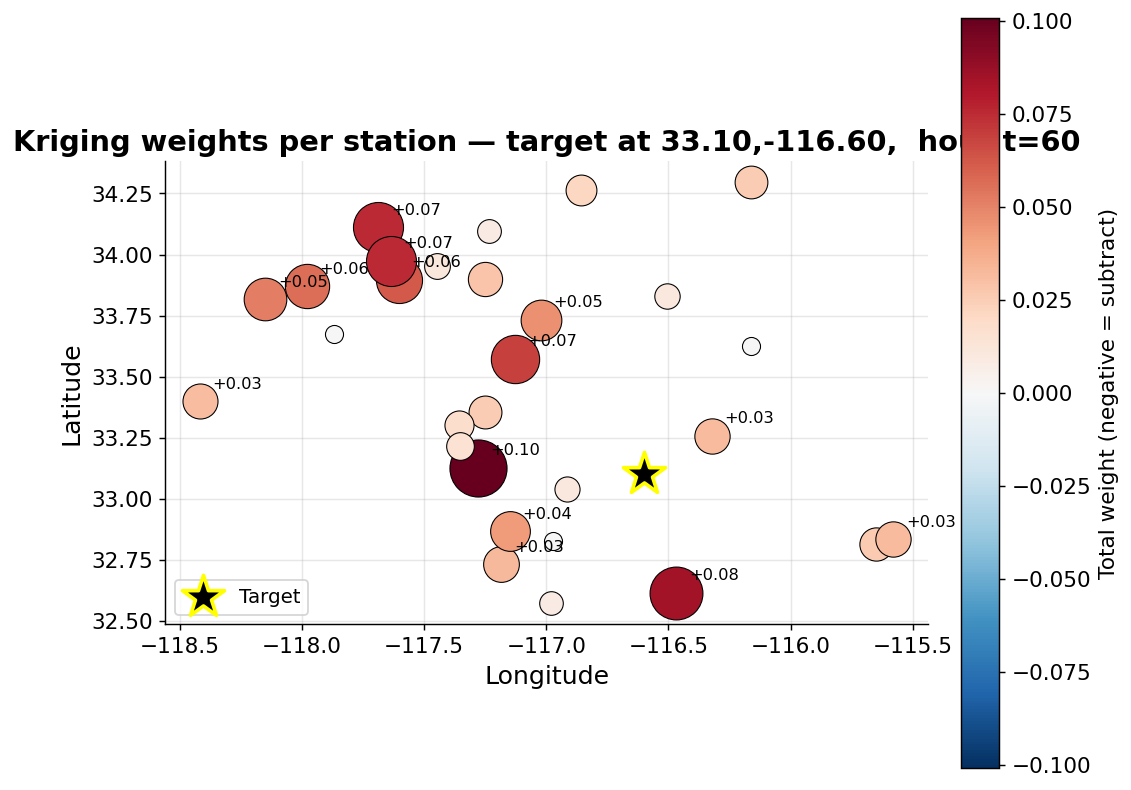

Top 5 contributors (abs weight):
  KCRQ0     weight=+0.101  dist=63.4 km  elev=101 m
  KCZZ0     weight=+0.085  dist=55.2 km  elev=802 m
  KCCB0     weight=+0.075  dist=151.0 km  elev=440 m
  KCNO0     weight=+0.075  dist=136.7 km  elev=198 m
  KF700     weight=+0.069  dist=72.0 km  elev=412 m
Sum of weights: 1.000  (must equal 1.0 for unbiasedness)


In [8]:

# Compute kriging weights for one target at one mid-point time — to illustrate
# the "each station contributes with a weight" picture
R_earth = 6371.0088
lat_rad = np.deg2rad(meta_sum["latitude"].values)
lon_rad = np.deg2rad(meta_sum["longitude"].values)
mean_lat = lat_rad.mean()
X_km = np.column_stack([
    R_earth * (lon_rad - lon_rad.mean()) * np.cos(mean_lat),
    R_earth * (lat_rad - lat_rad.mean()),
])
target_km = np.array([
    R_earth * (np.deg2rad(TARGET_LON) - lon_rad.mean()) * np.cos(mean_lat),
    R_earth * (np.deg2rad(TARGET_LAT) - lat_rad.mean()),
])

t_target = 60  # hour index within the week (mid-week afternoon, for illustration)
obs_rows = []; obs_tvals = []; obs_vals = []
for j in range(Y_s.shape[1]):
    v = Y_s[:, j]
    m = ~np.isnan(v)
    if m.any():
        obs_rows.append(X_km[m])
        obs_tvals.append(np.full(m.sum(), t_hours[j]))
        obs_vals.append(v[m])
X_obs = np.vstack(obs_rows); t_obs = np.concatenate(obs_tvals)
y_obs = np.concatenate(obs_vals)

H0 = cdist(np.array([target_km]), X_obs)
U0 = np.abs(t_hours[t_target] - t_obs)
joint = np.sqrt(H0[0] ** 2 + (max(p.k, 1e-6) * U0) ** 2)
nb_idx = np.argsort(joint)[:150]

X_nb = X_obs[nb_idx]; t_nb = t_obs[nb_idx]; y_nb = y_obs[nb_idx]

H_ii = cdist(X_nb, X_nb)
U_ii = np.abs(t_nb[:, None] - t_nb[None, :])
G = K.gamma_sum_metric(H_ii, U_ii, p)
n_nb = X_nb.shape[0]
A = np.zeros((n_nb + 1, n_nb + 1))
A[:n_nb, :n_nb] = G + 1e-10 * np.eye(n_nb)
A[:n_nb, n_nb] = 1.0
A[n_nb, :n_nb] = 1.0

h0 = cdist(np.array([target_km]), X_nb)[0]
u0 = np.abs(t_hours[t_target] - t_nb)
g0 = K.gamma_sum_metric(h0, u0, p)
b = np.ones(n_nb + 1); b[:n_nb] = g0
sol = np.linalg.lstsq(A, b, rcond=None)[0]
w = sol[:n_nb]

# For visualisation, aggregate weights to the 29 stations (sum over all time-tuples in this station)
weight_by_station = {}
for k_idx, lat_ll in enumerate(X_obs[nb_idx][:, 1]):
    pass  # dummy

# Instead: map each neighbour back to its (station, time) pair
# We lost the station index during stacking, so recompute mapping
stations = stations_s
mapping = []
for i, sid in enumerate(stations):
    for j in range(Y_s.shape[1]):
        v = Y_s[i, j]
        if not np.isnan(v):
            mapping.append((i, j))
# mapping is aligned with obs_rows stacking order
nb_station_idx = np.array([mapping[k][0] for k in nb_idx])
station_weight = np.zeros(len(stations))
for k_idx, si in enumerate(nb_station_idx):
    station_weight[si] += w[k_idx]

fig, ax = plt.subplots(figsize=(8.5, 6.8))
norm = Normalize(vmin=-max(abs(station_weight.min()), abs(station_weight.max())),
                 vmax=max(abs(station_weight.min()), abs(station_weight.max())))
cmap = plt.cm.RdBu_r
for i, sid in enumerate(stations):
    size = 100 + 900 * abs(station_weight[i]) / max(1e-9, np.abs(station_weight).max())
    c = cmap(norm(station_weight[i]))
    ax.scatter(meta_sum.loc[sid, "longitude"], meta_sum.loc[sid, "latitude"],
               s=size, color=c, edgecolor="black", linewidth=0.6, zorder=3)
ax.scatter([TARGET_LON], [TARGET_LAT], marker="*", color="black", s=600,
           edgecolor="yellow", linewidth=2, zorder=6, label="Target")
for i, sid in enumerate(stations):
    if abs(station_weight[i]) > 0.03:
        ax.annotate(f"{station_weight[i]:+.2f}",
                    (meta_sum.loc[sid, "longitude"], meta_sum.loc[sid, "latitude"]),
                    fontsize=9, xytext=(7, 7), textcoords="offset points")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Kriging weights per station — target at {TARGET_LAT:.2f},{TARGET_LON:.2f},  hour t={t_target}")
sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.04)
cb.set_label("Total weight (negative = subtract)", fontsize=12)
ax.legend(loc="lower left")
ax.set_aspect("equal")
fig.tight_layout()
savefig(fig, "slide3_kriging_weights")
plt.show()

print(f"Top 5 contributors (abs weight):")
order = np.argsort(-np.abs(station_weight))
for k in order[:5]:
    sid = stations[k]
    print(f"  {sid:8s}  weight={station_weight[k]:+.3f}  "
          f"dist={meta_sum.loc[sid, 'dist_km']:.1f} km  "
          f"elev={meta_sum.loc[sid, 'elevation']:.0f} m")
print(f"Sum of weights: {station_weight.sum():.3f}  (must equal 1.0 for unbiasedness)")


  saved slide4_prediction_trajectory.png


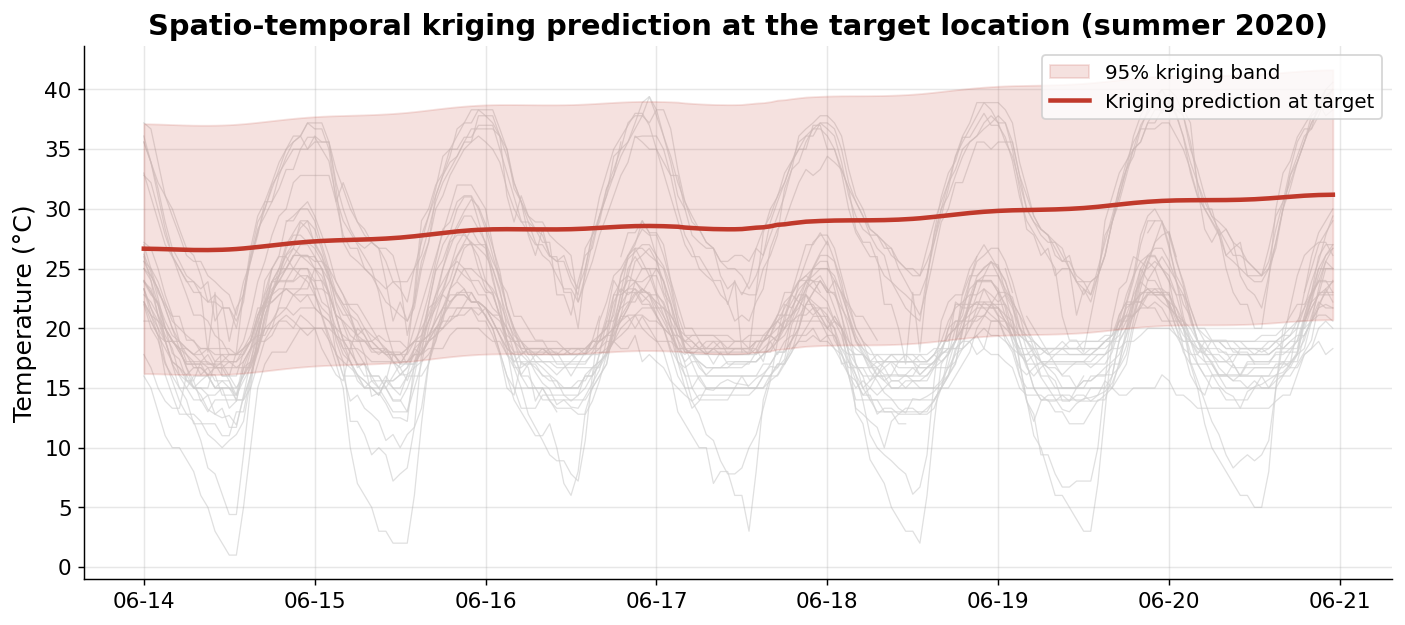

In [9]:

# Slide 4 plot A: Predicted trajectory at the target, over all 168 hours
X_pred = np.tile(target_km[None, :], (Y_s.shape[1], 1))
preds_target, kvar_target = K.ordinary_st_kriging_local(
    X_obs, t_obs, y_obs, X_pred, t_hours, p,
    n_neighbors=min(150, len(y_obs)),
)
ksd_target = np.sqrt(np.clip(kvar_target, 0, None))
times = wide_sum.index

fig, ax = plt.subplots(figsize=(11, 5))
for sid in wide_sum.columns:
    ax.plot(times, wide_sum[sid], color="lightgray", lw=0.7, alpha=0.7, zorder=1)
ax.fill_between(times, preds_target - 1.96 * ksd_target,
                preds_target + 1.96 * ksd_target,
                color="#c0392b", alpha=0.15, label="95% kriging band", zorder=2)
ax.plot(times, preds_target, color="#c0392b", lw=2.5,
        label="Kriging prediction at target", zorder=3)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Spatio-temporal kriging prediction at the target location (summer 2020)")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.legend(loc="upper right")
fig.tight_layout()
savefig(fig, "slide4_prediction_trajectory")
plt.show()


  saved slide4_prediction_zoom.png


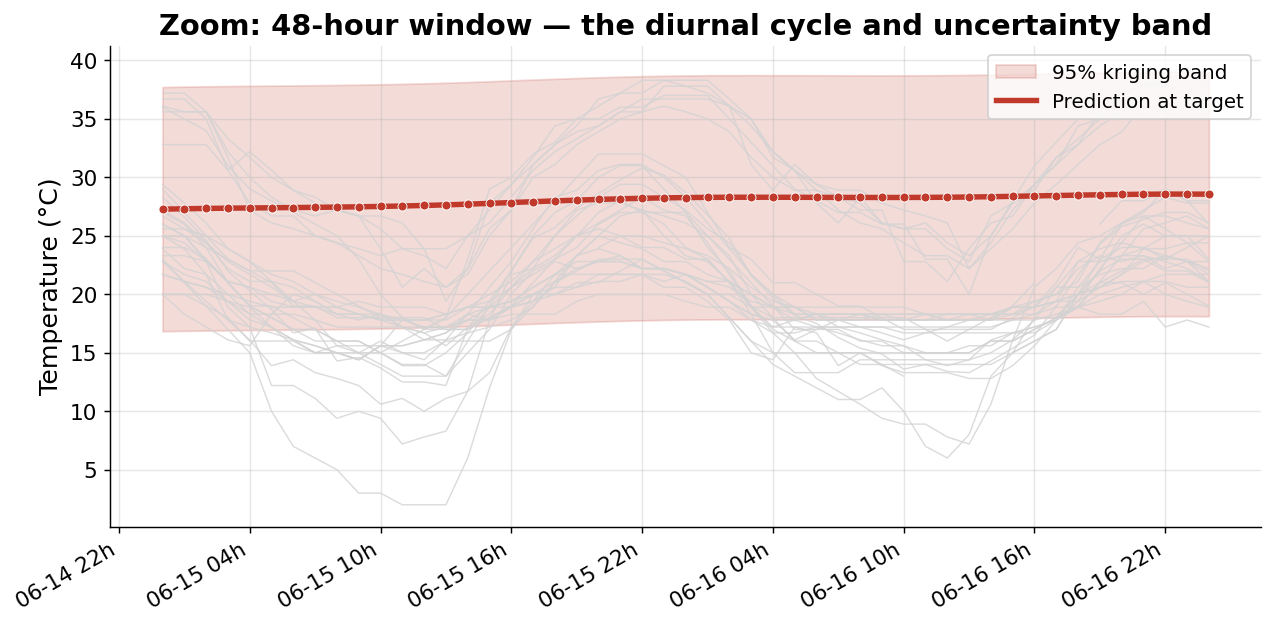

In [10]:

# Slide 4 plot B: zoom on a 2-day window to show the CI band clearly
two_day_mask = (times >= pd.Timestamp("2020-06-15")) & (times <= pd.Timestamp("2020-06-17"))

fig, ax = plt.subplots(figsize=(10, 5))
for sid in wide_sum.columns:
    ax.plot(times[two_day_mask], wide_sum[sid][two_day_mask],
            color="lightgray", lw=0.8, alpha=0.8)
ax.fill_between(times[two_day_mask],
                preds_target[two_day_mask] - 1.96 * ksd_target[two_day_mask],
                preds_target[two_day_mask] + 1.96 * ksd_target[two_day_mask],
                color="#c0392b", alpha=0.18, label="95% kriging band")
ax.plot(times[two_day_mask], preds_target[two_day_mask],
        color="#c0392b", lw=3, label="Prediction at target")
ax.scatter(times[two_day_mask], preds_target[two_day_mask],
           color="#c0392b", s=25, zorder=5, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Zoom: 48-hour window — the diurnal cycle and uncertainty band")
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(loc="upper right")
fig.tight_layout()
savefig(fig, "slide4_prediction_zoom")
plt.show()



---

# SLIDE 5 — Measuring accuracy

Narrative:

- We evaluate the kriging estimator with **leave-one-station-out cross-validation** (LOO-CV): every station is held out in turn, predicted from the others, and the prediction compared to its real hourly observations.
- Two metrics:
  - **RMSE** — root-mean-squared error, penalises large errors more strongly;
  - **MAE** — mean absolute error, easier to interpret in °C.
- We compare two kriging flavours: plain *ordinary* kriging (OK) and *regression* kriging (RK) in which an elevation trend is removed before kriging residuals, with both the trend and the variogram refitted inside each LOO fold (no leakage).
- We also compare a dense **near cluster** of stations vs. a **far cluster** to mirror the paper's "close local sensors vs. distant weather stations" question.


In [11]:

# Use the final_results.csv so slide numbers match the main notebook
results = pd.read_csv("kriging_figures/final_results.csv")
print(results.to_string(index=False))


                                  analysis     rmse      mae        r2           period
 Synthetic — weather stations (n=24, wide) 0.949322 0.869716  0.955591 7 synthetic days
Synthetic — local sensors (n=44, 1 km box) 0.154598 0.125127  0.998822 7 synthetic days
  Real NOAA — ordinary ST kriging (pooled) 4.582966 3.591220  0.478631      summer 2020
         Real NOAA — regression ST kriging 3.107896 2.476197  0.760235      summer 2020
  Real NOAA — ordinary ST kriging (pooled) 4.682470 3.398838  0.618624      autumn 2020
         Real NOAA — regression ST kriging 4.678003 3.103451  0.619351      autumn 2020
                10 nearest to target — LOO 5.434527 3.735083       NaN      summer 2020
             10 farthest from target — LOO 6.919844 4.821468       NaN      summer 2020
                HPWREN vs ordinary kriging 8.643455 7.321907 -2.303267        Sept 2013
              HPWREN vs regression kriging 7.302424 6.101936 -1.357779        Sept 2013


  saved slide5_rmse_mae_bars.png


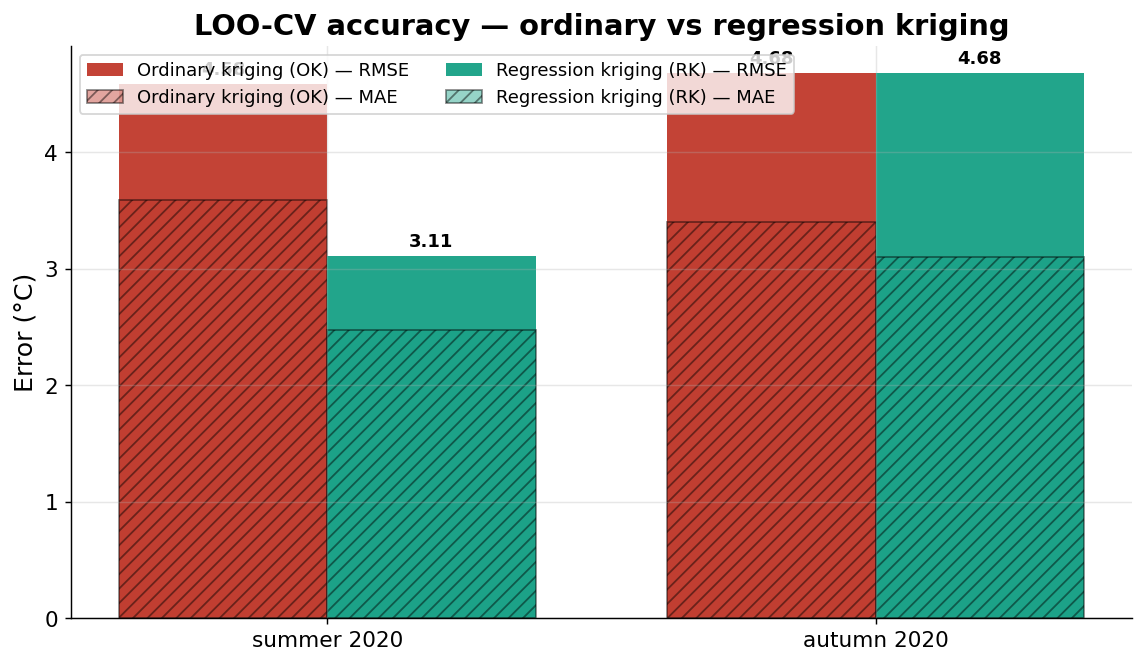

In [12]:

main_rows = results[results["analysis"].isin([
    "Real NOAA — ordinary ST kriging (pooled)",
    "Real NOAA — regression ST kriging",
])].copy()
main_rows = main_rows.sort_values(["period", "analysis"])

fig, ax = plt.subplots(figsize=(9, 5.3))
periods_list = ["summer 2020", "autumn 2020"]
methods = ["Real NOAA — ordinary ST kriging (pooled)", "Real NOAA — regression ST kriging"]
colors = {"Real NOAA — ordinary ST kriging (pooled)": "#c0392b",
          "Real NOAA — regression ST kriging": "#16a085"}
width = 0.38
x = np.arange(len(periods_list))

for m_idx, m in enumerate(methods):
    vals_rmse = [main_rows[(main_rows["period"] == per) & (main_rows["analysis"] == m)]["rmse"].iloc[0]
                 for per in periods_list]
    vals_mae = [main_rows[(main_rows["period"] == per) & (main_rows["analysis"] == m)]["mae"].iloc[0]
                for per in periods_list]
    label_ok = "Ordinary kriging (OK)" if "ordinary" in m else "Regression kriging (RK)"
    offset = -width / 2 if m_idx == 0 else width / 2
    ax.bar(x + offset, vals_rmse, width, color=colors[m], alpha=0.95, label=f"{label_ok} — RMSE")
    ax.bar(x + offset, vals_mae, width, color=colors[m], alpha=0.45, edgecolor="black",
           label=f"{label_ok} — MAE", hatch="///")

ax.set_xticks(x); ax.set_xticklabels(periods_list)
ax.set_ylabel("Error (°C)")
ax.set_title("LOO-CV accuracy — ordinary vs regression kriging")
ax.legend(fontsize=10, loc="upper left", ncol=2)
for xi, per in zip(x, periods_list):
    for m_idx, m in enumerate(methods):
        off = -width / 2 if m_idx == 0 else width / 2
        v = main_rows[(main_rows["period"] == per) & (main_rows["analysis"] == m)]["rmse"].iloc[0]
        ax.text(xi + off, v + 0.08, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
fig.tight_layout()
savefig(fig, "slide5_rmse_mae_bars")
plt.show()


  saved slide5_scatter_and_errors.png


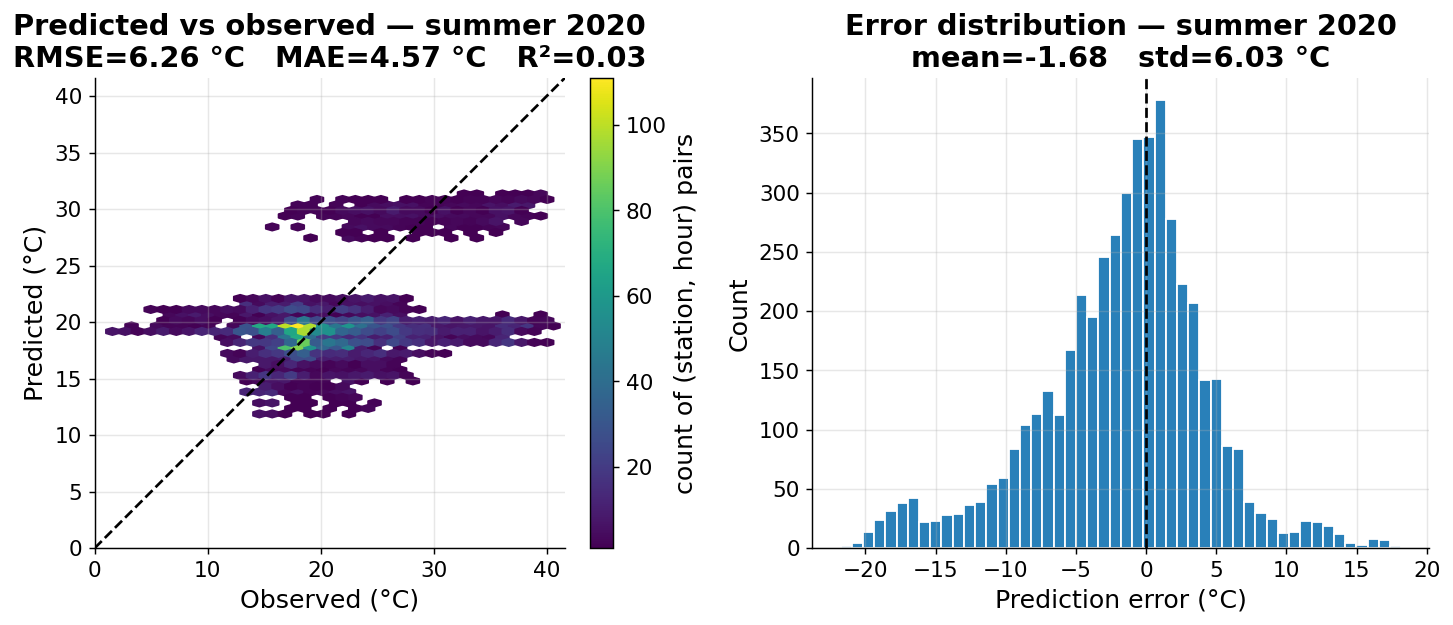

In [13]:

# Scatter plot predicted vs observed pooled across stations (ordinary kriging, summer)
# Use LOO predictions computed on the fly for summer 2020 via the local-neighbourhood kriging
Y_hat = np.full_like(Y_s, np.nan)
for i in range(Y_s.shape[0]):
    keep = np.arange(Y_s.shape[0]) != i
    obs_rows = []; obs_tvals = []; obs_vals = []
    for j in range(Y_s.shape[1]):
        v = Y_s[keep, j]
        m = ~np.isnan(v)
        if m.any():
            obs_rows.append(X_km[keep][m])
            obs_tvals.append(np.full(m.sum(), t_hours[j]))
            obs_vals.append(v[m])
    if not obs_rows:
        continue
    X_obs_i = np.vstack(obs_rows); t_obs_i = np.concatenate(obs_tvals)
    y_obs_i = np.concatenate(obs_vals)
    X_pred_i = np.tile(X_km[i:i + 1], (Y_s.shape[1], 1))
    preds_i, _ = K.ordinary_st_kriging_local(
        X_obs_i, t_obs_i, y_obs_i, X_pred_i, t_hours, p,
        n_neighbors=min(120, len(y_obs_i)),
    )
    Y_hat[i] = preds_i

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
y_true = Y_s.ravel(); y_pred = Y_hat.ravel()
mask = np.isfinite(y_true) & np.isfinite(y_pred)
h = ax.hexbin(y_true[mask], y_pred[mask], gridsize=35, cmap="viridis", mincnt=1)
lo = min(y_true[mask].min(), y_pred[mask].min()) - 1
hi = max(y_true[mask].max(), y_pred[mask].max()) + 1
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("Observed (°C)")
ax.set_ylabel("Predicted (°C)")
rmse_pool = K.rmse(y_true, y_pred); mae_pool = K.mae(y_true, y_pred); r2_pool = K.r2_score(y_true, y_pred)
ax.set_title(f"Predicted vs observed — summer 2020\nRMSE={rmse_pool:.2f} °C   MAE={mae_pool:.2f} °C   R²={r2_pool:.2f}")
cb = fig.colorbar(h, ax=ax, fraction=0.045, pad=0.04); cb.set_label("count of (station, hour) pairs")

ax = axes[1]
err = (y_pred - y_true)[mask]
ax.hist(err, bins=50, color="#2980b9", edgecolor="white")
ax.axvline(0, ls="--", color="black", lw=1.5)
ax.set_xlabel("Prediction error (°C)")
ax.set_ylabel("Count")
ax.set_title(f"Error distribution — summer 2020\nmean={err.mean():+.2f}   std={err.std():.2f} °C")

fig.tight_layout()
savefig(fig, "slide5_scatter_and_errors")
plt.show()


  saved slide5_final_summary.png


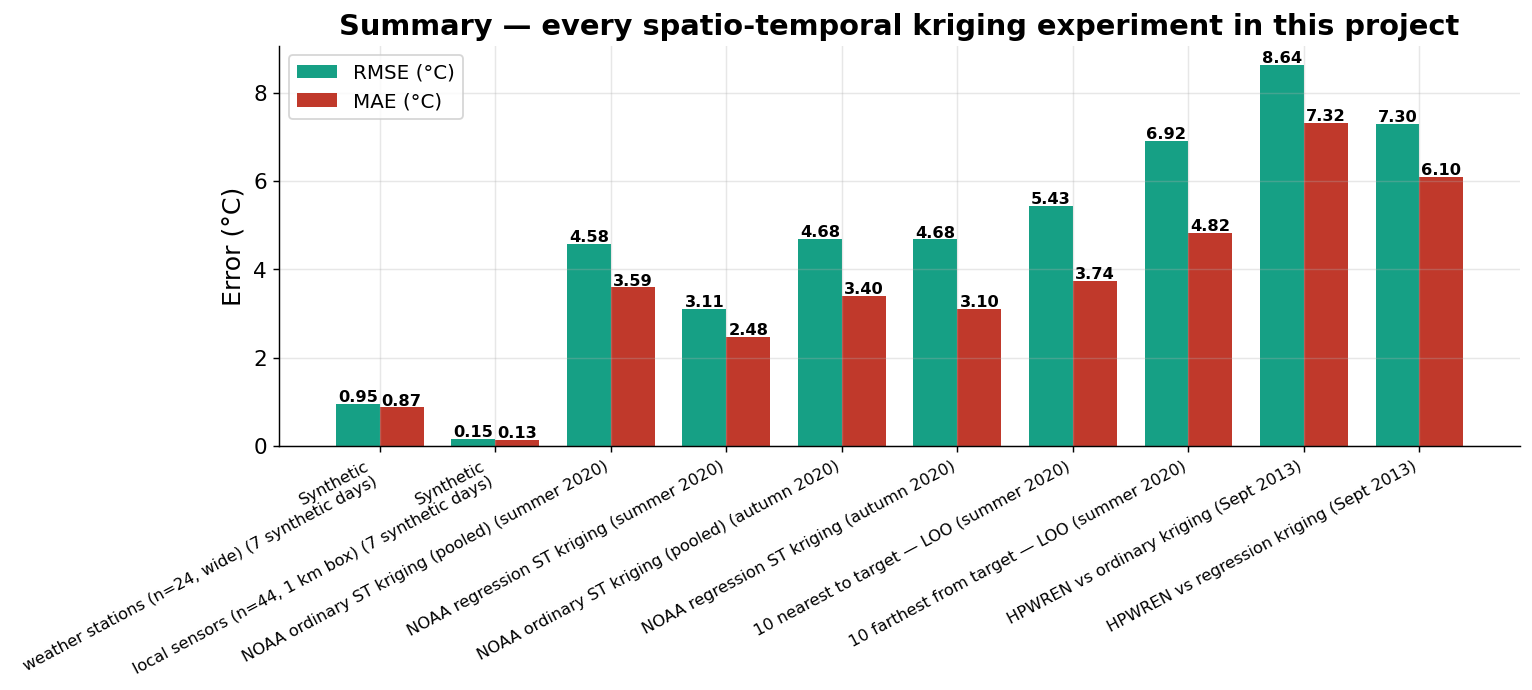

In [14]:

# Final bar chart: every experiment side by side, scaled for presentation
fig, ax = plt.subplots(figsize=(12, 5.5))
xs = np.arange(len(results))
width = 0.38
rmse_vals = results["rmse"].values
mae_vals = results["mae"].values
labels = [a.replace("Real NOAA — ", "NOAA ")
            .replace("Synthetic — ", "Synthetic\n") + f" ({p})"
          for a, p in zip(results["analysis"], results["period"])]
ax.bar(xs - width/2, rmse_vals, width, color="#16a085", label="RMSE (°C)")
ax.bar(xs + width/2, mae_vals, width, color="#c0392b", label="MAE (°C)")
for x, v in zip(xs - width/2, rmse_vals):
    ax.text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
for x, v in zip(xs + width/2, mae_vals):
    ax.text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(xs)
ax.set_xticklabels(labels, rotation=28, ha="right", fontsize=9)
ax.set_ylabel("Error (°C)")
ax.set_title("Summary — every spatio-temporal kriging experiment in this project")
ax.legend()
fig.tight_layout()
savefig(fig, "slide5_final_summary")
plt.show()
